In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from xgboost import XGBClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter


In [5]:
df = pd.read_csv("C:/My_Projects/churn-prediction-mlops-pipeline/data/processed-data/feature_engineered_data.csv")

In [8]:
X = df.drop(columns=["Churn_Label"])
y = df["Churn_Label"]

In [10]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # ✅ use scaled test data

# Initialize model
model = LogisticRegression(class_weight='balanced', max_iter=1000)

# Train the model
model.fit(X_train_scaled, y_train)

# Predict on scaled test set
y_pred = model.predict(X_test_scaled)  # ✅ use X_test_scaled

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


[[756 280]
 [ 65 308]]
              precision    recall  f1-score   support

    No Churn       0.92      0.73      0.81      1036
       Churn       0.52      0.83      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



In [12]:
# Initialize Random Forest with class_weight balanced
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["No Churn", "Churn"]))


Confusion Matrix:
[[955  81]
 [210 163]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.92      0.87      1036
       Churn       0.67      0.44      0.53       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



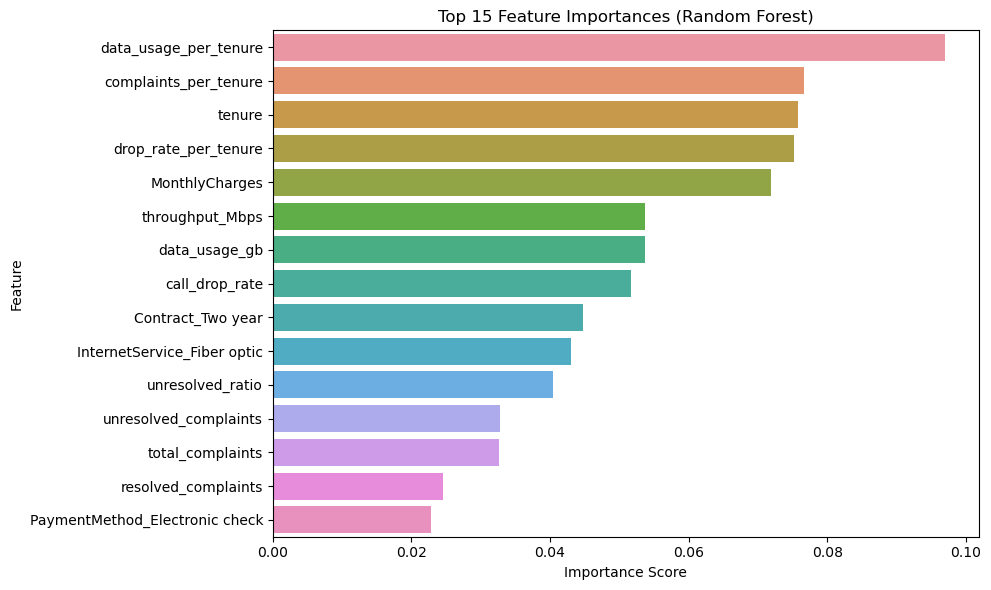

In [13]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [14]:
top_n_features = feature_importances.sort_values(ascending=False).head(10).index
X_top = X[top_n_features]

In [15]:
#Xgboost training
# Compute class weight ratio manually (to handle imbalance)
from collections import Counter

counter = Counter(y_train)
class_weight_ratio = counter[0] / counter[1]  # No Churn / Churn

In [17]:
xgb = XGBClassifier(
    scale_pos_weight=class_weight_ratio, 
    use_label_encoder=False, 
    eval_metric='logloss'
)

xgb.fit(X_train_scaled, y_train)
y_pred = xgb.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


C:\Users\nchan\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [20:06:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:
[[863 173]
 [134 239]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.83      0.85      1036
       Churn       0.58      0.64      0.61       373

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.79      1409



In [20]:
# Define parameter grid
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.3],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

# Calculate class imbalance ratio if not already defined
from collections import Counter
counter = Counter(y_train)
class_weight_ratio = counter[0] / counter[1]  # assuming 0 = No Churn, 1 = Churn

# Initialize randomized search
rs = RandomizedSearchCV(
    estimator=XGBClassifier(scale_pos_weight=class_weight_ratio, use_label_encoder=False, eval_metric='logloss'),
    param_distributions=params,
    scoring="f1",
    cv=5,
    n_iter=10,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit model
rs.fit(X_train_scaled, y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\nchan\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [20:08:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.3],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=1)

In [22]:

# 1. Best parameters
print("Best Parameters Found:")
print(rs.best_params_)

# 2. Use best estimator to predict
best_model = rs.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# 3. Evaluate
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


Best Parameters Found:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

Confusion Matrix:
[[752 284]
 [ 59 314]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.93      0.73      0.81      1036
       Churn       0.53      0.84      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



In [24]:

# 1. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Compute Class Imbalance Ratio
counter = Counter(y_train)
class_weight_ratio = counter[0] / counter[1]

# 4. Best XGBoost Model from RandomizedSearchCV
best_model = XGBClassifier(
    scale_pos_weight=class_weight_ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    subsample=0.7,
    n_estimators=300,
    max_depth=7,
    learning_rate=0.01,
    colsample_bytree=0.6,
    random_state=42
)

# 5. Train
best_model.fit(X_train_scaled, y_train)

# 6. Predict
y_pred = best_model.predict(X_test_scaled)

# 7. Evaluate
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


C:\Users\nchan\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [20:10:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:
[[811 225]
 [ 77 296]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.78      0.84      1036
       Churn       0.57      0.79      0.66       373

    accuracy                           0.79      1409
   macro avg       0.74      0.79      0.75      1409
weighted avg       0.82      0.79      0.80      1409

